<a href="https://colab.research.google.com/github/ssk-algoverse/sae-binding/blob/main/FolderTest/LowValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
!pip install transformer_lens

In [3]:
# What are we trying to create for a dataset:
# A0a, B1b, C0c, A1d,
# Given that these represent Subject - Relation - Attribute, so A0a could be: A(ris) 0(lives) a(arizona)

In [62]:
from tqdm import tqdm
E = 100 # num entities
A = 100 # num attributes
T = 10 # num types/relations
SEP = E+A+T # as seperator between relations
Q = E+A+T+1 # question token
PAD = E+A+T+2
D_VOCAB = E+A+T+3

N_WORLDS = 100_000 # (also dataset size)
MIN_FACTS, MAX_FACTS = 4, 8
SEED = 0

ENTITIES   = np.arange(0, E) # 0..99
ATTRS      = np.arange(E, E + A) # 100..199
TYPES      = np.arange(E+A, E+A + T) # 200..204

rng = np.random.default_rng(SEED)

def produce_example(num_relations: int):
    """
    Generate a single training example with a UNIQUE, RANDOM world of facts.
    """
    # Just randomly choose entities, types and attributes, for each example
    chosen_entities = rng.choice(ENTITIES, size=num_relations, replace=False)
    chosen_types = rng.choice(TYPES, size=num_relations, replace=False)
    chosen_attrs = rng.choice(ATTRS, size=num_relations, replace=False)

    # Then create the list of relations for this specific example (this is the "random world")
    facts = []
    for i in range(num_relations):
        facts.append((int(chosen_entities[i]), int(chosen_types[i]), int(chosen_attrs[i])))

    # Pick one of these random facts to be the query
    q_idx = rng.integers(0, num_relations)
    Eq, Tq, Aq = facts[q_idx]

    # Create sequence
    seq = []
    for (e, t, a) in facts:
        seq.extend([e, t, a, SEP])
    seq.extend([Eq, Tq, Q])

    label = Aq
    return seq, label

rows = []
for _ in tqdm(range(N_WORLDS)): # N_WORLDS == number of examples
    num_relations = int(rng.integers(MIN_FACTS, MAX_FACTS + 1))
    seq, label = produce_example(num_relations)
    rows.append({"tokens": seq, "label": label})

df = pd.DataFrame(rows)

100%|██████████| 100000/100000 [00:05<00:00, 18096.85it/s]


In [63]:
df

,tokens,label
0,"[59, 206, 129, 210, 48, 202, 108, 210, 29, 204...",107
1,"[24, 205, 167, 210, 98, 202, 190, 210, 58, 207...",199
2,"[70, 200, 196, 210, 85, 209, 122, 210, 22, 204...",140
3,"[19, 200, 118, 210, 87, 209, 194, 210, 65, 206...",142
4,"[44, 201, 192, 210, 75, 204, 190, 210, 40, 200...",168
...,...,...
99995,"[61, 202, 132, 210, 56, 205, 197, 210, 76, 207...",132
99996,"[59, 202, 189, 210, 96, 203, 139, 210, 36, 205...",111
99997,"[34, 209, 144, 210, 33, 207, 178, 210, 75, 204...",178
99998,"[61, 204, 163, 210, 30, 203, 170, 210, 83, 201...",170


In [64]:
### Model

In [76]:
from transformer_lens import HookedTransformer, HookedTransformerConfig

cfg = HookedTransformerConfig(
    n_layers=2,
    n_heads=1,
    d_model=256,
    d_head=256,
    d_mlp=1024,
    n_ctx=64,
    d_vocab=D_VOCAB,
    act_fn="gelu",
    attn_only=False,
    normalization_type="LN",
)
model = HookedTransformer(cfg)

In [77]:
import os
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

In [78]:
IGNORE_INDEX = -100

class EntityBindingDataset(Dataset):
    def __init__(self, dataframe, parse_tokens_if_str=True):
        self.df = dataframe.reset_index(drop=True)
        self.parse_tokens_if_str = parse_tokens_if_str

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = row["tokens"]
        tokens = torch.tensor(seq, dtype=torch.long)
        label  = torch.tensor(int(row["label"]), dtype=torch.long)
        return tokens, label

In [79]:
def train_collate_fn(batch, rng=np.random.default_rng()):
    max_len = max(len(seq) for seq,_ in batch)
    B = len(batch)
    toks   = torch.full((B, max_len), PAD, dtype=torch.long)
    target = torch.full((B, max_len), IGNORE_INDEX, dtype=torch.long)

    for i, (seq, label) in enumerate(batch):
        s = shuffle_facts(seq.tolist() if torch.is_tensor(seq) else seq, rng)
        L = len(s)
        toks[i, :L] = torch.tensor(s, dtype=torch.long)
        target[i, L-1] = label
    return toks, target

def val_collate_fn(batch):
    max_len = max(len(seq) for seq,_ in batch)
    B = len(batch)
    toks   = torch.full((B, max_len), PAD, dtype=torch.long)
    target = torch.full((B, max_len), IGNORE_INDEX, dtype=torch.long)

    for i, (seq, label) in enumerate(batch):
        s = seq.tolist() if torch.is_tensor(seq) else seq
        L = len(s)
        toks[i, :L] = torch.tensor(s, dtype=torch.long)
        target[i, L-1] = label
    return toks, target


In [80]:
def shuffle_facts(seq, rng=np.random.default_rng()):
    seps = [i for i,t in enumerate(seq) if t == SEP]
    context = seq[:seps[-1]+1]
    query_part = seq[seps[-1]+1:]
    Eq, Tq = query_part[0], query_part[1]
    facts = [context[i:i+4] for i in range(0, len(context), 4)]
    rng.shuffle(facts)

    return [x for f in facts for x in f] + query_part

In [81]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_dataset = EntityBindingDataset(train_df)
val_dataset = EntityBindingDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=train_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=val_collate_fn)

In [82]:
len(train_dataset)

80000

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.98), weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
writer = SummaryWriter("runs/entity_binding_hooked_transformer")

Moving model to device:  cuda


In [84]:
def compute_accuracy(logits: torch.Tensor, targets: torch.Tensor, ignore_index: int = IGNORE_INDEX):
    """
    Accuracy over positions where targets != ignore_index.
    Returns correct_count and total_count
    """
    with torch.no_grad():
        mask = targets.ne(ignore_index)
        total = mask.sum().item()
        preds = logits.argmax(dim=-1)
        correct = preds.masked_select(mask).eq(targets.masked_select(mask)).sum().item()
        return correct, total

In [85]:
!export CUDA_LAUNCH_BLOCKING=1

In [86]:
num_epochs = 20
global_step = 0

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    total_train_correct = 0
    total_train_count = 0
    for input_tokens, targets in train_loader:
        input_tokens, targets = input_tokens.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(input_tokens)  # shape: [B, T, d_vocab]
        loss = criterion(logits.view(-1, logits.size(-1)),
                          targets.view(-1)) #just flattens it
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        c, n = compute_accuracy(logits, targets)
        total_train_correct += c
        total_train_count += n
        step_acc = (c / n) if n else 0.0
        writer.add_scalar("Loss/train", loss.item(), global_step)
        writer.add_scalar("Acc/train_step", step_acc, global_step)
        global_step += 1

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = (total_train_correct / total_train_count) if total_train_count else 0.0
    print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.3f}")

    model.eval()
    total_val_loss = 0
    total_val_correct = 0
    total_val_count = 0
    with torch.no_grad():
        for input_tokens, targets in val_loader:
            input_tokens, targets = input_tokens.to(device), targets.to(device)
            logits = model(input_tokens)
            loss = criterion(logits.view(-1, logits.size(-1)),
                          targets.view(-1))
            total_val_loss += loss.item()
            c, n = compute_accuracy(logits, targets)
            total_val_correct += c
            total_val_count += n

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = (total_val_correct / total_val_count) if total_val_count else 0.0
    print(f"[Epoch {epoch+1}] Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.3f}")
    writer.add_scalar("Loss/val", avg_val_loss, global_step)
    writer.add_scalar("Acc/val", val_acc, global_step)

writer.close()
print("Training complete.")

[Epoch 1] Train Loss: 2.7567 | Train Acc: 0.205
[Epoch 1] Val Loss: 1.9921 | Val Acc: 0.345
[Epoch 2] Train Loss: 1.8043 | Train Acc: 0.366
[Epoch 2] Val Loss: 1.8227 | Val Acc: 0.348
[Epoch 3] Train Loss: 1.6507 | Train Acc: 0.381
[Epoch 3] Val Loss: 1.7348 | Val Acc: 0.349
[Epoch 4] Train Loss: 1.5610 | Train Acc: 0.399
[Epoch 4] Val Loss: 1.6366 | Val Acc: 0.384
[Epoch 5] Train Loss: 1.1249 | Train Acc: 0.559
[Epoch 5] Val Loss: 1.0118 | Val Acc: 0.613
[Epoch 6] Train Loss: 0.8579 | Train Acc: 0.669
[Epoch 6] Val Loss: 0.8598 | Val Acc: 0.648
[Epoch 7] Train Loss: 0.8172 | Train Acc: 0.678
[Epoch 7] Val Loss: 1.1104 | Val Acc: 0.620
[Epoch 8] Train Loss: 0.7985 | Train Acc: 0.681
[Epoch 8] Val Loss: 0.9229 | Val Acc: 0.647
[Epoch 9] Train Loss: 0.7626 | Train Acc: 0.687
[Epoch 9] Val Loss: 0.8620 | Val Acc: 0.654
[Epoch 10] Train Loss: 0.7396 | Train Acc: 0.695
[Epoch 10] Val Loss: 0.8654 | Val Acc: 0.653
[Epoch 11] Train Loss: 0.7317 | Train Acc: 0.699
[Epoch 11] Val Loss: 0.8972 |

In [87]:
train_acc_of = [
    0.153, 0.238, 0.273, 0.323, 0.377,
    0.453, 0.538, 0.627, 0.728, 0.804,
    0.861, 0.898, 0.920, 0.932, 0.939,
    0.946, 0.953, 0.951, 0.959, 0.960
]

val_acc_of = [
    0.188, 0.187, 0.190, 0.193, 0.195,
    0.181, 0.182, 0.172, 0.177, 0.198,
    0.179, 0.187, 0.195, 0.184, 0.181,
    0.185, 0.180, 0.181, 0.175, 0.176
]

train_acc_2at = [
    0.168, 0.196, 0.349, 0.416, 0.457,
    0.514, 0.679, 0.685, 0.691, 0.705,
    0.779, 0.799, 0.811, 0.869, 0.923,
    0.927, 0.932, 0.924, 0.934, 0.935
]

val_acc_2at = [
    0.178, 0.176, 0.357, 0.383, 0.417,
    0.632, 0.647, 0.652, 0.643, 0.682,
    0.753, 0.759, 0.761, 0.887, 0.906,
    0.903, 0.908, 0.915, 0.917, 0.921
]

train_acc_1at = [
    0.205, 0.366, 0.381, 0.399, 0.559,
    0.669, 0.678, 0.681, 0.687, 0.695,
    0.699, 0.708, 0.714, 0.721, 0.729,
    0.738, 0.748, 0.753, 0.762, 0.771
]

val_acc_1at = [
    0.345, 0.348, 0.349, 0.384, 0.613,
    0.648, 0.620, 0.647, 0.654, 0.653,
    0.647, 0.626, 0.634, 0.650, 0.650,
    0.657, 0.660, 0.655, 0.653, 0.653
]


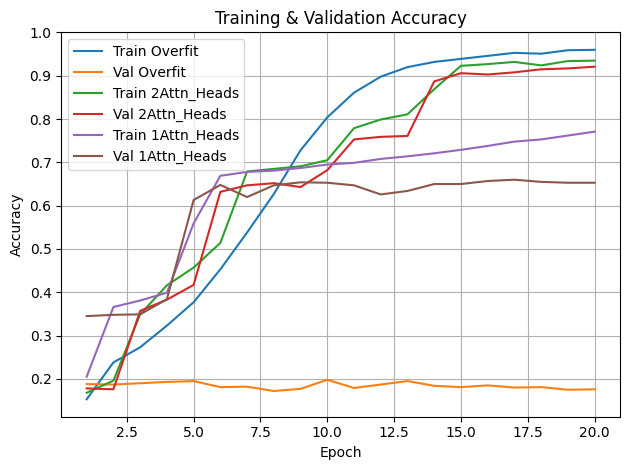

In [89]:
import matplotlib.pyplot as plt

# ---- data ----
train_acc_of = [
    0.153, 0.238, 0.273, 0.323, 0.377,
    0.453, 0.538, 0.627, 0.728, 0.804,
    0.861, 0.898, 0.920, 0.932, 0.939,
    0.946, 0.953, 0.951, 0.959, 0.960
]

val_acc_of = [
    0.188, 0.187, 0.190, 0.193, 0.195,
    0.181, 0.182, 0.172, 0.177, 0.198,
    0.179, 0.187, 0.195, 0.184, 0.181,
    0.185, 0.180, 0.181, 0.175, 0.176
]

train_acc_2at = [
    0.168, 0.196, 0.349, 0.416, 0.457,
    0.514, 0.679, 0.685, 0.691, 0.705,
    0.779, 0.799, 0.811, 0.869, 0.923,
    0.927, 0.932, 0.924, 0.934, 0.935
]

val_acc_2at = [
    0.178, 0.176, 0.357, 0.383, 0.417,
    0.632, 0.647, 0.652, 0.643, 0.682,
    0.753, 0.759, 0.761, 0.887, 0.906,
    0.903, 0.908, 0.915, 0.917, 0.921
]

train_acc_1at = [
    0.205, 0.366, 0.381, 0.399, 0.559,
    0.669, 0.678, 0.681, 0.687, 0.695,
    0.699, 0.708, 0.714, 0.721, 0.729,
    0.738, 0.748, 0.753, 0.762, 0.771
]

val_acc_1at = [
    0.345, 0.348, 0.349, 0.384, 0.613,
    0.648, 0.620, 0.647, 0.654, 0.653,
    0.647, 0.626, 0.634, 0.650, 0.650,
    0.657, 0.660, 0.655, 0.653, 0.653
]

# ---- plot ----
epochs = range(1, len(train_acc_of) + 1)

plt.plot(epochs, train_acc_of, label="Train Overfit")
plt.plot(epochs, val_acc_of,   label="Val Overfit")
plt.plot(epochs, train_acc_2at, label="Train 2Attn_Heads")
plt.plot(epochs, val_acc_2at,   label="Val 2Attn_Heads")
plt.plot(epochs, train_acc_1at, label="Train 1Attn_Heads")
plt.plot(epochs, val_acc_1at,   label="Val 1Attn_Heads")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
